# Hand Gesture Classification Using MediaPipe Landmarks from the HaGRID Dataset


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np

import cv2 
import joblib
import os
import subprocess

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, f1_score
)

from sklearn.model_selection import GridSearchCV
from IPython.display import Video, display, HTML


from utility import normalize_landmarks_df, plot_hand_landmarks
from mlflow_utils import run_tuning_mlflow, load_registered_model

The dataset is hosted on Google Drive as a CSV file. We download it directly into a Pandas DataFrame using the file's share ID.

In [2]:
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

### About the Dataset

The 21 landmarks correspond to key anatomical points on the hand:

| Landmark | Description | Landmark | Description |
|----------|-------------|----------|-------------|
| 0 (Wrist) | Base of the hand | 11 | PIP of middle finger |
| 1 | CMC of thumb | 12 | DIP of middle finger  |
| 2 | MCP of thumb | 13 | Tip of middle finger |
| 3 | IP of thumb | 14 | MCP of ring finger |
| 4 | Tip of thumb | 15 | PIP of ring finger |
| 5 | MCP of index finger | 16 | DIP of ring finger |
| 6 | PIP of index finger | 17 | Tip of ring finger |
| 7 | DIP of index finger | 18 | MCP of pinky |
| 8 | Tip of index finger | 19 | PIP of pinky |
| 9 | MCP of middle finger | 20 | Tip of pinky |
| 10 | CMC of middle finger | | |

![Hand Landmarks Diagram](hand_landmarks.png)

### Missing Values Check

Confirm that there are **zero** missing values across the entire dataset.

In [4]:
df.isnull().sum().sum()

np.int64(0)

### Duplicate Rows Check

Confirm that there are **zero** duplicated values across the entire dataset.

In [5]:
df.duplicated().sum()

np.int64(0)

## 2. Data Visualization

### Data Distribution

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


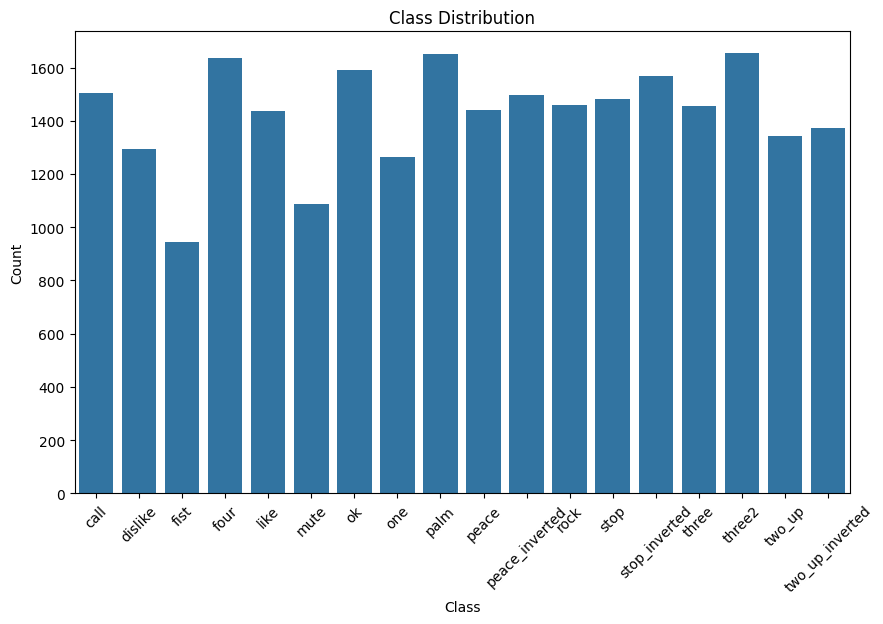

In [6]:
print(df['label'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Since the dataset contains **2D/3D landmark coordinates** (not raw images), we can reconstruct the hand skeleton by plotting the 21 landmarks and connecting them according to the **MediaPipe hand topology**.

The connections follow the natural finger structure:
- **Wrist** → base of each finger
- **Thumb:** 0 → 1 → 2 → 3 → 4
- **Index:** 0 → 5 → 6 → 7 → 8
- **Middle:** 0 → 9 → 10 → 11 → 12
- **Ring:** 0 → 13 → 14 → 15 → 16
- **Pinky:** 0 → 17 → 18 → 19 → 20

Below we visualize one random sample from each gesture class.

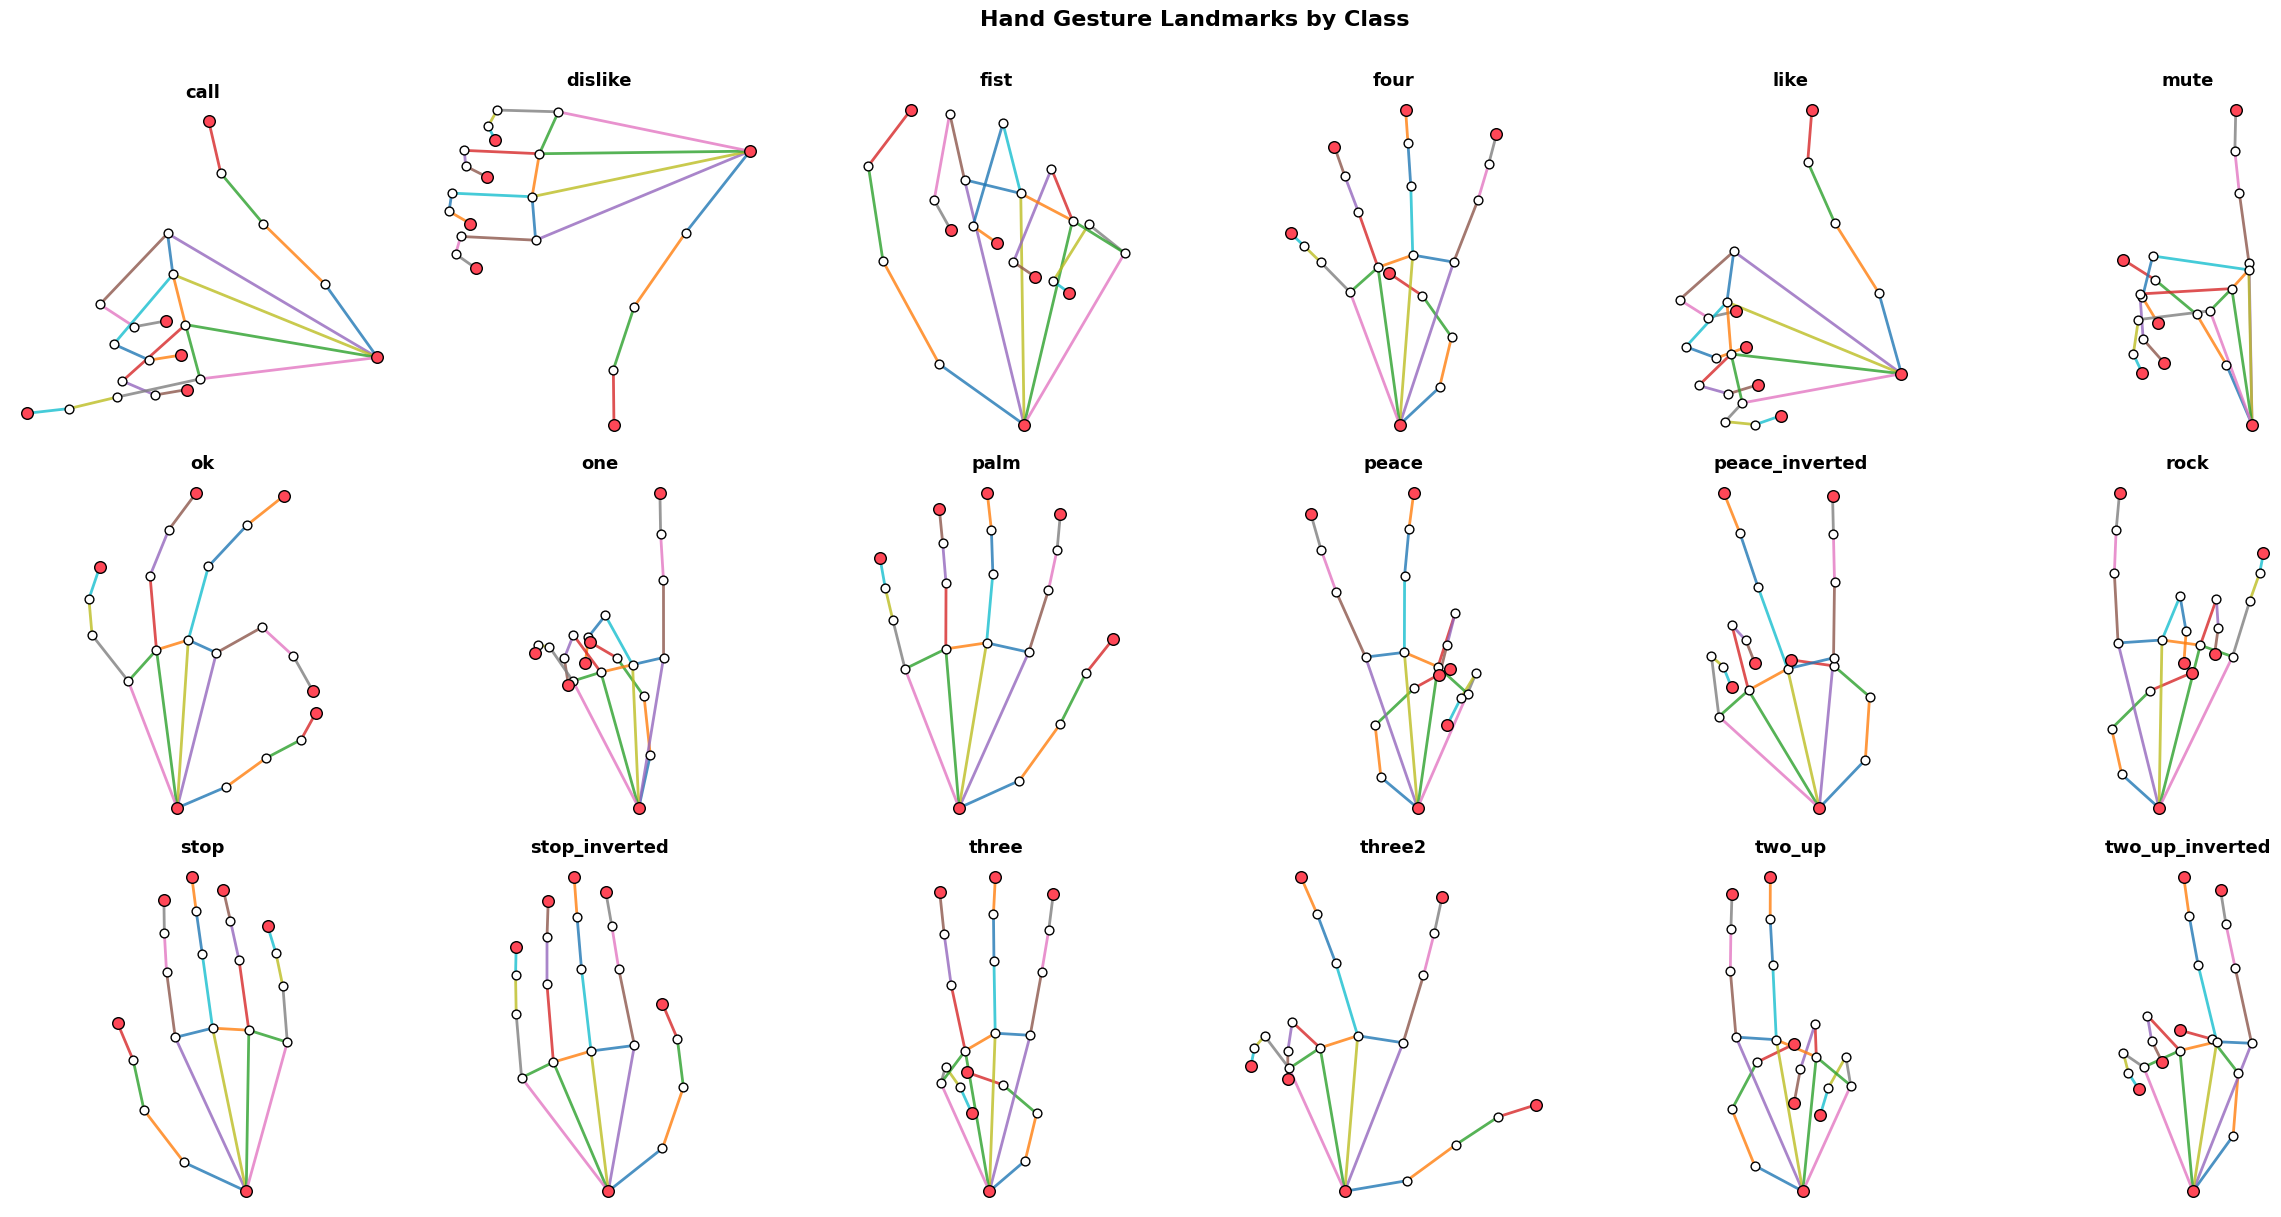

In [7]:
labels = sorted(df['label'].unique())
n_labels = len(labels)
cols = 6
rows = (n_labels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for idx, label in enumerate(labels):
    sample = df[df['label'] == label].sample(1, random_state=42).iloc[0]
    plot_hand_landmarks(sample, axes[idx], title=label)


fig.suptitle('Hand Gesture Landmarks by Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

### Normalize Landmarks

Raw landmark coordinates vary with hand position and size in the image. To make the features **translation- and scale-invariant**, we normalize each sample by:

1. **Centering** — subtract the **wrist** (landmark 1) coordinates from the X and Y values so the wrist becomes the origin `(0, 0)`.
2. **Scaling** — divide the X and Y coordinates by the **Euclidean distance** between the wrist and the middle finger tip (landmark 13). Z coordinates are intentionally left untouched.

This ensures the model learns **hand shape and finger pose** rather than absolute pixel position or hand size.

In [8]:
df_normalized = normalize_landmarks_df(df)
df_normalized.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649205e-07,-0.169097,-0.328246,0.004224,-0.508248,-0.501843,0.005798,-0.846234,...,-1.266027,-0.058407,-0.020450,-1.533293,0.026072,-0.024577,-1.759842,0.074168,-0.026722,call
1,0.0,0.0,-2.345265e-07,-0.040618,-0.498120,-0.011102,0.191551,-0.982869,-0.021096,0.349889,...,1.397837,-0.121412,-0.038175,1.691695,-0.091952,-0.037336,1.966655,-0.086635,-0.036136,call
2,0.0,0.0,-2.417307e-07,0.172978,-0.420554,-0.000184,0.437913,-0.820949,-0.009687,0.621006,...,1.404373,0.187884,-0.044068,1.676609,0.247919,-0.040469,1.913833,0.270275,-0.038301,call
3,0.0,0.0,-1.233261e-07,-0.020056,-0.468103,-0.002824,0.070355,-0.911821,-0.008911,0.114792,...,1.280797,-0.094800,-0.027622,1.529073,-0.079763,-0.027863,1.738331,-0.086693,-0.027723,call
4,0.0,0.0,-1.622995e-07,-0.009611,-0.482677,-0.002884,0.111650,-1.075914,-0.008115,0.131602,...,1.327537,-0.331511,-0.025113,1.612488,-0.386821,-0.024087,1.849127,-0.464123,-0.023486,call


### Train Test Split

In [9]:
X = df_normalized.drop(columns=['label'])
y = df_normalized['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, shuffle=True, stratify=y)

In [11]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20540, 63)
y_train shape: (20540,)
X_test shape: (5135, 63)
y_test shape: (5135,)


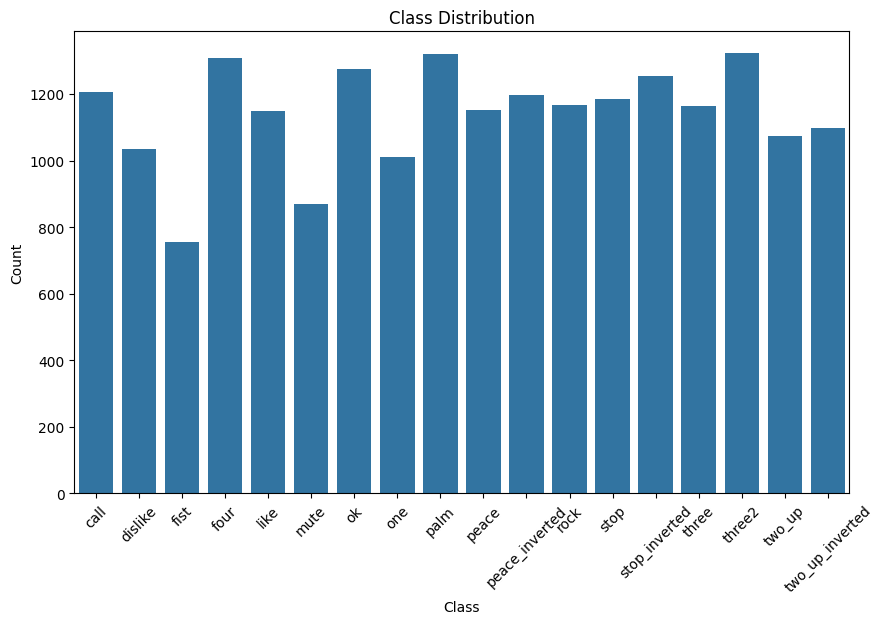

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x=sorted(y_train))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


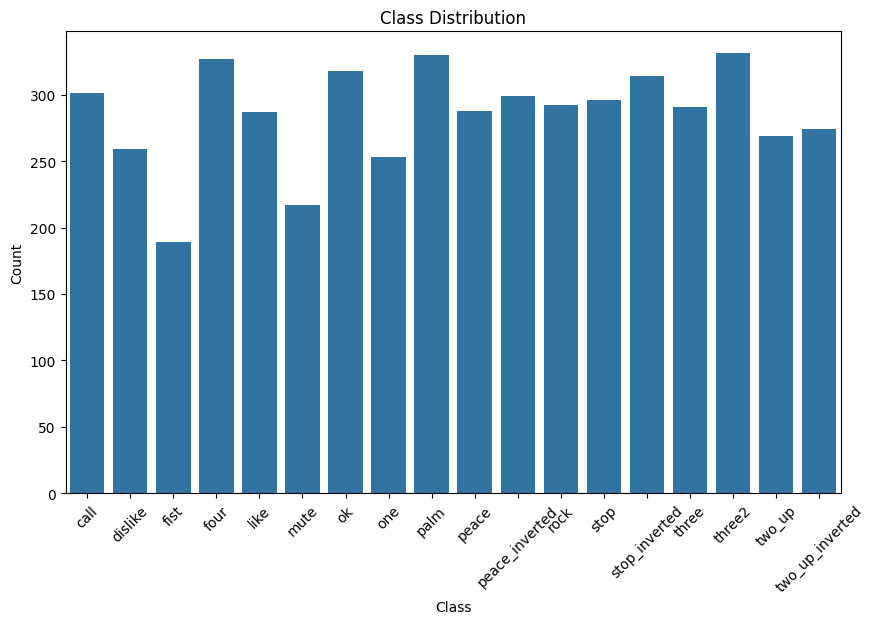

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x=sorted(y_test))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 4. Model Training & Selection

In [14]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

run_tuning_mlflow(
    experiment_name="Hand_Gesture_Classification",
    run_name="KNN_RandomSearch",
    X_train=X_train,
    y_train=y_train,
    model=KNeighborsClassifier(),
    param_dist=knn_params,
    n_iter=6
    )

2026/02/27 00:42:53 INFO mlflow.tracking.fluent: Experiment with name 'Hand_Gesture_Classification' does not exist. Creating a new experiment.


Starting Hyperparameter Tuning: KNN_RandomSearch
Merged dataset logged successfully to MLflow.
Running KNN_RandomSearch_Trial_1 with params: {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:42:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:42:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Running KNN_RandomSearch_Trial_2 with params: {'weights': 'distance', 'n_neighbors': 9, 'metric': 'manhattan'}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:43:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:43:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


...

/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:43:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:43:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Running KNN_RandomSearch_Trial_6 with params: {'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:43:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:43:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuning Complete. Best F1-Macro Score: 0.9756
Best Params: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [15]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

run_tuning_mlflow(
    experiment_name="Hand_Gesture_Classification",
    run_name="SVM_GridSearch_Params",
    X_train=X_train,
    y_train=y_train,
    model=SVC(), 
    param_dist=svm_params,
    n_iter=6,  
    cv=5       
)

Starting Hyperparameter Tuning: SVM_GridSearch_Params
Merged dataset logged successfully to MLflow.
Running SVM_GridSearch_Params_Trial_1 with params: {'kernel': 'linear', 'C': 0.1}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
2026/02/27 00:44:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:44:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Running SVM_GridSearch_Params_Trial_2 with params: {'kernel': 'rbf', 'C': 0.1}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Running SVM_GridSearch_Params_Trial_3 with params: {'kernel': 'linear', 'C': 1}


...

/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
2026/02/27 00:48:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:48:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Running SVM_GridSearch_Params_Trial_6 with params: {'kernel': 'rbf', 'C': 10}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
2026/02/27 00:48:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:48:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuning Complete. Best F1-Macro Score: 0.9766
Best Params: {'kernel': 'rbf', 'C': 10}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [16]:
rf_params = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20]
}

run_tuning_mlflow(
    experiment_name="Hand_Gesture_Classification",
    run_name="RF_GridSearch_Params",
    X_train=X_train,
    y_train=y_train,
    model=RandomForestClassifier(), 
    param_dist=rf_params,
    n_iter=9,  
    cv=5   
)

Starting Hyperparameter Tuning: RF_GridSearch_Params
Merged dataset logged successfully to MLflow.
Running RF_GridSearch_Params_Trial_1 with params: {'n_estimators': 10, 'max_depth': None}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:49:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:49:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Running RF_GridSearch_Params_Trial_2 with params: {'n_estimators': 50, 'max_depth': None}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:49:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:49:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Running RF_GridSearch_Params_Trial_3 with params: {'n_estimators': 100, 'max_depth': None}


...

/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:54:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:54:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Running RF_GridSearch_Params_Trial_9 with params: {'n_estimators': 100, 'max_depth': 20}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
2026/02/27 00:55:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 00:55:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuning Complete. Best F1-Macro Score: 0.9756
Best Params: {'n_estimators': 100, 'max_depth': None}


/home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 5. Model Evaluation

We evaluate all four models (**KNN**, **SVM**, **Random Forest**) on the held-out test set using accuracy, precision, recall, and F1-score. We also display confusion matrices and classification reports.

In [21]:
knn = load_registered_model("KNN")
svm = load_registered_model("SVM")
rf = load_registered_model("Random Forest")

# Predictions
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)

models_preds = {
    'KNN': y_pred_knn,
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf}

/home/zizo/iti/ML-01/project/mlflow_utils.py:147: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(model_name)


Loading version 1 (Stage: None)
Loading version 1 (Stage: None)
Loading version 1 (Stage: None)


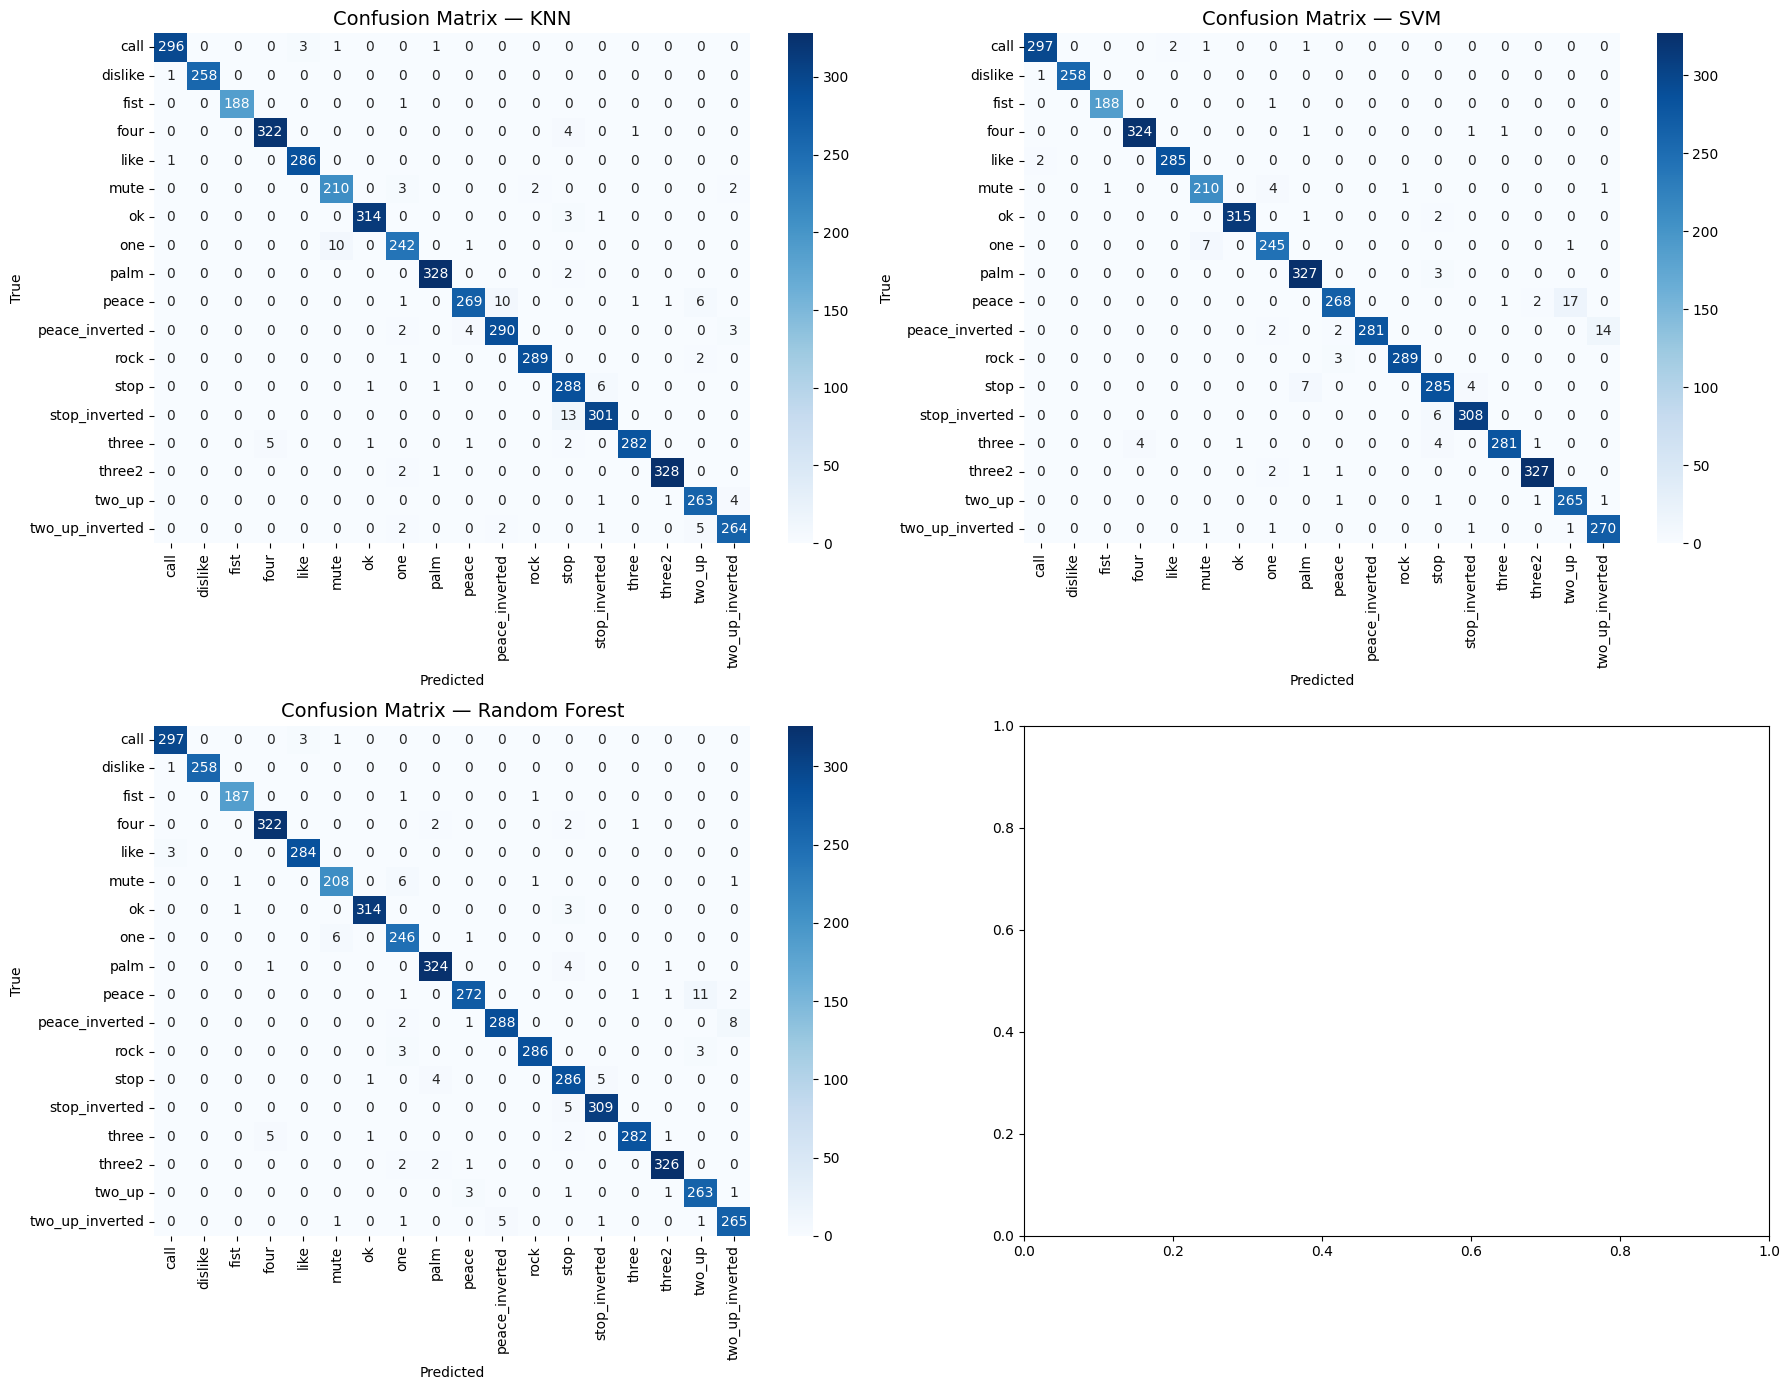

In [22]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=axes[idx],
                xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
    axes[idx].set_title(f'Confusion Matrix — {name}', fontsize=14)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

## 6. Video Classification

In [ ]:
from process_video import run_live_prediction

run_live_prediction()

  Live Hand Gesture Recognition & Recording
Loading ML model...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772093882.806492   10740 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772093882.827516   10740 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



  ✓ Webcam ready. Recording to 'videos/output/output_rf.mp4'.
  ✓ Press and hold 'q' in the video window to stop and save.


W0000 00:00:1772093883.565052   10740 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
QFontDatabase: Cannot find font directory /home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/zizo/iti/ML-01/project/hand_gesture/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory


[Stopped] 'q' pressed. Shutting down camera...

[Processing] Converting 'videos/output/output_rf.mp4' to H.264 (this may take a few seconds)...
  ✓ Successfully converted to H.264: videos/output/output_rf.mp4

Exited gracefully.


## 7. Conclusion

### Final Recommendation: i will go with the Random Forest
